In [101]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *

In [103]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
# train_loader, val_loader = get_dataloaders(spectra, fractions)
unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = unbatched_data.dataset[0][0].size(0)
print(unbatched_data.batch_size)
print(num_spectra)

Device: cpu
1
210


In [ ]:
convolution = ConvEncoder([unbatched_data.batch_size, 32, 32], [128, 128], c_d={'pad': 1}, num_spectra=num_spectra)
criterion = nn.MSELoss()
optimizer = optim.Adam(convolution.parameters(), lr=1e-3)

# print(convolution.encoder)
# print(convolution.decoder)

n_epochs = 10

In [105]:
losses = []
for epoch in range(1, n_epochs+1):
    convolution.train()
    tot_loss = 0
    for xb, yb in unbatched_data:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    losses.append(tot_loss / len(unbatched_data.dataset))

print(losses)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 210])) that is different to the input size (torch.Size([210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[0.006545179956630794]


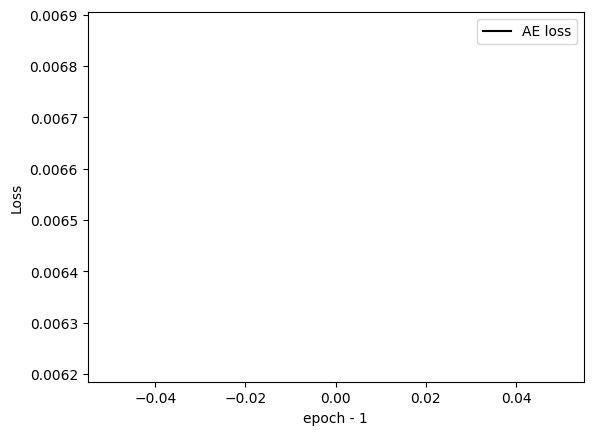

In [106]:
plt.plot(losses, color='black', label='AE loss')
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [107]:
val_spectrum = next(iter(unbatched_data))[0]
print(val_spectrum)
print(convolution(val_spectrum))
print(criterion(convolution(val_spectrum), val_spectrum))


tensor([[0.0595, 0.0644, 0.0700, 0.0762, 0.0823, 0.0878, 0.0926, 0.0969, 0.1014,
         0.1064, 0.1120, 0.1178, 0.1244, 0.1314, 0.1384, 0.1451, 0.1513, 0.1566,
         0.1612, 0.1656, 0.1710, 0.1753, 0.1790, 0.1842, 0.1892, 0.1937, 0.1981,
         0.2024, 0.2076, 0.2148, 0.2245, 0.2346, 0.2436, 0.2526, 0.2604, 0.2665,
         0.2720, 0.2762, 0.2807, 0.2849, 0.2889, 0.2926, 0.2959, 0.3000, 0.3041,
         0.3077, 0.3112, 0.3145, 0.3176, 0.3204, 0.3224, 0.3249, 0.3282, 0.3281,
         0.3292, 0.3323, 0.3362, 0.3407, 0.3441, 0.3475, 0.3519, 0.3567, 0.3594,
         0.3626, 0.3658, 0.3688, 0.3720, 0.3750, 0.3781, 0.3804, 0.3821, 0.3812,
         0.3787, 0.3805, 0.3827, 0.3856, 0.3901, 0.3938, 0.3961, 0.3988, 0.4010,
         0.4038, 0.4071, 0.4108, 0.4144, 0.4180, 0.4207, 0.4235, 0.4263, 0.4288,
         0.4305, 0.4319, 0.4315, 0.4292, 0.4251, 0.4106, 0.3803, 0.3842, 0.3673,
         0.3694, 0.3603, 0.3558, 0.3514, 0.3479, 0.3461, 0.3481, 0.3504, 0.3518,
         0.3573, 0.3641, 0.3